# How a cosmological IC is generated, end-to-end

This notebook walks through the algorithm that produces the IC HDF5
files analysed in `01_quickstart.ipynb` and
`02_box_size_sensitivity.ipynb`. It runs in 2D so every step can be
plotted, but the math is identical to the 3D production pipeline
(`run_pipeline.sh` → MUSIC2 → SWIFT-format HDF5).

The full theory is in `notes/cosmo_ic.pdf` (fluid equations, ZA, 2LPT,
P(k) measurement, MUSIC2 implementation details). This notebook is its
executable companion.

## What an IC has to provide

An N-body simulation needs particle positions and velocities at some
starting redshift $z_{\rm start}$, drawn from a Gaussian random field
with the linear matter power spectrum $P(k, z_{\rm start})$. The
Zel'dovich approximation (1LPT) gives both from a single displacement
field $\boldsymbol\Psi$:

$$\mathbf x(\mathbf q, z) = \mathbf q + \boldsymbol\Psi(\mathbf q, z),
\qquad
\mathbf v(\mathbf q, z) = a\,H(z)\,f(z)\,\boldsymbol\Psi(\mathbf q, z),$$

where $\mathbf q$ is a uniform Lagrangian lattice and $\boldsymbol\Psi$
is curl-free with

$$\nabla\!\cdot\boldsymbol\Psi = -\delta.$$

So the algorithm is:

1. Get the target $P(k)$ at $z_{\rm start}$ (e.g. CLASS).
2. Build a Gaussian random $\delta$ with that $P(k)$.
3. Solve $\boldsymbol\Psi$ from $\nabla\!\cdot\boldsymbol\Psi = -\delta$
   in Fourier: $\tilde{\boldsymbol\Psi}_{\mathbf k} = i\mathbf k\,\tilde\delta_{\mathbf k}/k^2$.
4. Place particles at $\mathbf q + \boldsymbol\Psi$ with velocity
   $aHf\,\boldsymbol\Psi$.

The rest of this notebook does that on a 2D grid.

In [1]:
# If launched from notebooks/, change up to the project root so
# the relative 'data/' paths used below resolve correctly.
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('cwd:', os.getcwd())

cwd: /home/jgkim/Dropbox/Projects/cosmo-pipeline


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from icpipe import LinearTheory

# Box and grid (2D)
N    = 256
L    = 500.0           # Mpc/h
dx   = L / N
V    = L ** 2

# Cosmology
H0      = 67.11
OMEGA_M = 0.3158
h       = H0 / 100.0
Z_START = 200

# Wavenumber grids (h/Mpc)
kx = np.fft.fftfreq(N, d=dx) * 2 * np.pi
KX, KY = np.meshgrid(kx, kx, indexing='ij')
Kmag   = np.sqrt(KX**2 + KY**2)

print(f'box: {L} Mpc/h, grid {N}x{N}, dx = {dx:.3g} Mpc/h')
print(f'k_fund = {2*np.pi/L:.4g} h/Mpc, k_Nyq = {np.pi/dx:.4g} h/Mpc')

box: 500.0 Mpc/h, grid 256x256, dx = 1.95 Mpc/h
k_fund = 0.01257 h/Mpc, k_Nyq = 1.608 h/Mpc


## 1. Target $P(k)$ from CLASS at $z_{\rm start}$

CLASS provides the linear matter power spectrum at any redshift. We
reuse `class_pk_z200_pk.dat`, the table the production pipeline writes
during its CLASS step. `icpipe.LinearTheory` wraps the table and exposes
$P_\delta(k)$ along with the linear background quantities $a$, $H(z)$,
$f(z)$, $aHf$.

a = 4.975e-03,  H(z) = 1.07e+05 km/s/Mpc,  f = 1,  aHf = 535 km/s/Mpc


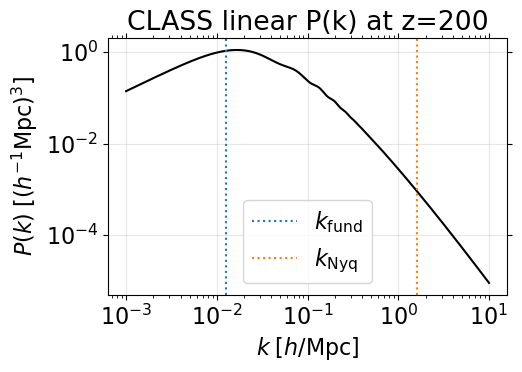

In [3]:
th = LinearTheory.from_class('data/class_pk_z200_pk.dat',
                              z=Z_START, h=h, Omega_m=OMEGA_M)
print(f'a = {th.a:.3e},  H(z) = {th.H_kmsMpc:.3g} km/s/Mpc,  '
      f'f = {th.f_growth:.4g},  aHf = {th.aHf:.3g} km/s/Mpc')

k_show = np.logspace(-3, 1, 300)

plt.figure(figsize=(5.5, 4))
plt.loglog(k_show, th.Pk(k_show), 'k-')
plt.axvline(2*np.pi/L, color='C0', ls=':', label=r'$k_{\rm fund}$')
plt.axvline(np.pi/dx,  color='C1', ls=':', label=r'$k_{\rm Nyq}$')
plt.xlabel(r'$k\;[h/\mathrm{Mpc}]$')
plt.ylabel(r'$P(k)\;[(h^{-1}\mathrm{Mpc})^3]$')
plt.title(f'CLASS linear P(k) at z={Z_START}')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Build $\delta$ as a Gaussian random field

Adopt the Fourier conventions used in `notes/cosmo_ic.pdf`:

$$\delta(\mathbf x) = \frac{1}{V}\sum_{\mathbf k} \tilde\delta_{\mathbf k}\,e^{i\mathbf k\cdot\mathbf x},
\qquad
\tilde\delta_{\mathbf k} = \int_V \delta(\mathbf x)\,e^{-i\mathbf k\cdot\mathbf x}\,d^d x,$$

and the power spectrum by $\langle|\tilde\delta_{\mathbf k}|^2\rangle = V\,P(k)$.

To realize a discrete sample with this property:

1. Draw real-space white noise $\mu_n \sim \mathcal{N}(0, 1)$ at every cell.
2. FFT it (numpy convention, no $1/N$): $\hat\mu_{\mathbf k} = \sum_n \mu_n\,e^{-2\pi i\,\mathbf k\cdot\mathbf n / N}$, so $\langle|\hat\mu_{\mathbf k}|^2\rangle = N^d$.
3. Multiply by a per-mode amplitude that gives the right $\langle|\hat\delta_{\mathbf k}|^2\rangle$.

Working through the discrete-vs-continuum bookkeeping (a $dx^d$ factor
on the forward FFT relates the two), the recipe is

$$\hat\delta_{\mathbf k} = \sqrt{P(k)\,N^d / V}\;\hat\mu_{\mathbf k},
\qquad \hat\delta_{\mathbf 0} = 0,$$

and `np.fft.ifftn` recovers the real-space $\delta(\mathbf x)$.

(We use the 3D ΛCDM $P(k)$ as a 2D demonstration spectrum; the
algorithm is identical, only the dimension-counting differs.)

In [4]:
rng = np.random.default_rng(42)

mu      = rng.standard_normal((N, N))
mu_k    = np.fft.fftn(mu)
sigma_k = np.sqrt(th.Pk(Kmag) * N**2 / V)        # 2D: N^d -> N^2
delta_k = sigma_k * mu_k
delta_k[0, 0] = 0.0                              # zero mean
delta   = np.fft.ifftn(delta_k).real

print(f'delta rms      = {delta.std():.4g}  '
      f'(linear regime: << 1 at z={Z_START})')
print(f'delta min/max  = {delta.min():+.3g} / {delta.max():+.3g}')

delta rms      = 0.04268  (linear regime: << 1 at z=200)
delta min/max  = -0.179 / +0.179


At $z=200$ the field is firmly linear: $\delta$ has rms $\sim 10^{-3}$
and the (very faint) over- and under-dense regions trace what will, by
$z\!=\!0$, become filaments and voids — compressed by $D(z\!=\!200)\approx 1/200$ relative to today.

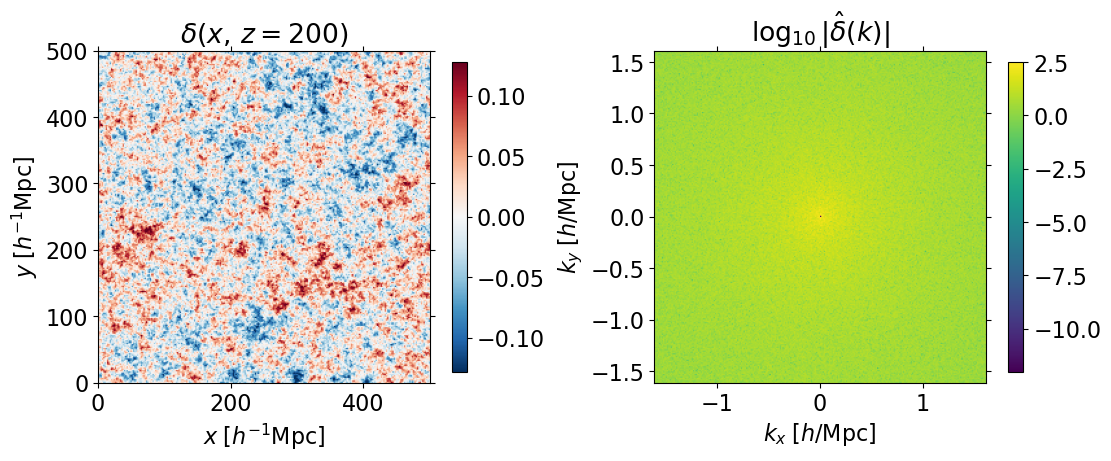

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
vmax = 3 * delta.std()

im = ax[0].imshow(delta, cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                   origin='lower', extent=[0, L, 0, L])
ax[0].set_title(rf'$\delta(x,\,z={Z_START})$')
ax[0].set_xlabel(r'$x\;[h^{-1}\mathrm{Mpc}]$')
ax[0].set_ylabel(r'$y\;[h^{-1}\mathrm{Mpc}]$')
plt.colorbar(im, ax=ax[0], fraction=0.045)

im = ax[1].imshow(np.log10(np.abs(np.fft.fftshift(delta_k)) + 1e-12),
                   cmap='viridis', origin='lower',
                   extent=[-np.pi/dx, np.pi/dx, -np.pi/dx, np.pi/dx])
ax[1].set_title(r'$\log_{10}|\hat\delta(k)|$')
ax[1].set_xlabel(r'$k_x\;[h/\mathrm{Mpc}]$')
ax[1].set_ylabel(r'$k_y\;[h/\mathrm{Mpc}]$')
plt.colorbar(im, ax=ax[1], fraction=0.045)
plt.show()

## 3. Displacement field $\boldsymbol\Psi$ from the Poisson equation

Because $\boldsymbol\Psi$ is curl-free, write $\boldsymbol\Psi = \nabla\phi$.
Then $\nabla\!\cdot\boldsymbol\Psi = \nabla^2\phi = -\delta$, giving

$$\hat\phi_{\mathbf k} = \tilde\delta_{\mathbf k}/k^2,
\qquad
\tilde{\boldsymbol\Psi}_{\mathbf k} = i\mathbf k\,\hat\phi_{\mathbf k} = i\mathbf k\,\tilde\delta_{\mathbf k}/k^2.$$

In Fourier the Poisson solve is one division per mode — that's the
whole reason MUSIC2 is fast.

In [6]:
K2     = KX**2 + KY**2
with np.errstate(divide='ignore'):
    inv_K2 = np.where(K2 > 0, 1.0/K2, 0.0)

Psi_x_k = 1j * KX * inv_K2 * delta_k
Psi_y_k = 1j * KY * inv_K2 * delta_k
Psi_x   = np.fft.ifftn(Psi_x_k).real     # Mpc/h
Psi_y   = np.fft.ifftn(Psi_y_k).real

Pmag    = np.sqrt(Psi_x**2 + Psi_y**2)
print(f'|Psi| rms        = {Pmag.std():.4g} Mpc/h '
      f'({Pmag.std()/dx:.4g} cells, {Pmag.std()/L:.4%} of box)')
print(f'|Psi| max / dx   = {Pmag.max()/dx:.3g}   '
      f'(ZA stays valid while < 1; production ICs are O(0.1))')

|Psi| rms        = 0.3344 Mpc/h (0.1712 cells, 0.0669% of box)
|Psi| max / dx   = 1.02   (ZA stays valid while < 1; production ICs are O(0.1))


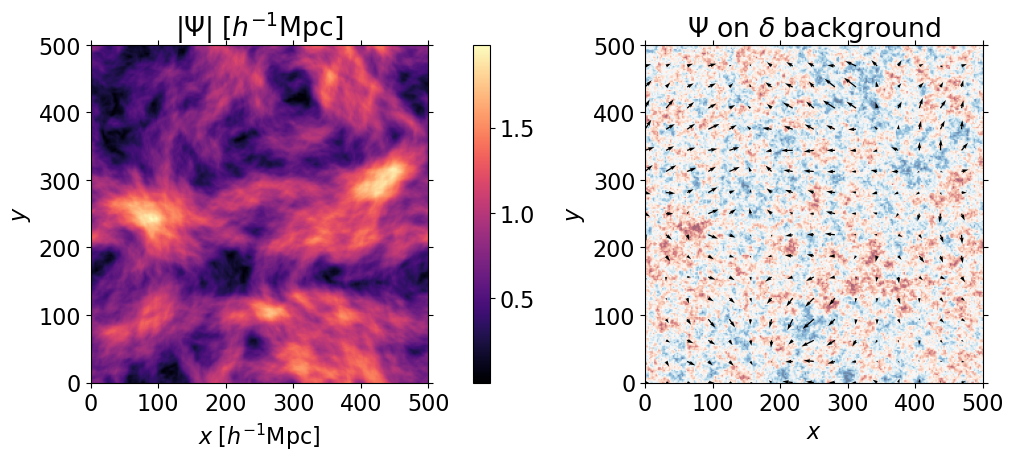

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

im = ax[0].imshow(Pmag, cmap='magma', origin='lower',
                   extent=[0, L, 0, L])
ax[0].set_title(r'$|\Psi|\;[h^{-1}\mathrm{Mpc}]$')
ax[0].set_xlabel(r'$x\;[h^{-1}\mathrm{Mpc}]$'); ax[0].set_ylabel(r'$y$')
plt.colorbar(im, ax=ax[0], fraction=0.045)

# Displacement vectors on a coarse subgrid, overlaid on delta
step = N // 16
qx, qy = np.meshgrid(np.arange(N)*dx, np.arange(N)*dx, indexing='ij')
ax[1].imshow(delta, cmap='RdBu_r', vmin=-3*delta.std(), vmax=3*delta.std(),
              origin='lower', extent=[0, L, 0, L], alpha=0.6)
ax[1].quiver(qx[::step, ::step], qy[::step, ::step],
              Psi_x[::step, ::step], Psi_y[::step, ::step],
              scale=40, color='k')
ax[1].set_title(r'$\Psi$ on $\delta$ background')
ax[1].set_xlabel(r'$x$'); ax[1].set_ylabel(r'$y$')
plt.show()

## 4. Particles: positions and velocities

Place one tracer per cell on the Lagrangian lattice $\mathbf q$, displace
by $\boldsymbol\Psi(\mathbf q)$, and assign $\mathbf v = aHf\,\boldsymbol\Psi$.
The pre-factor `aHf` is the linear-theory peculiar-velocity amplitude
at $z_{\rm start}$ — same number `LinearTheory` printed above.

In [8]:
xx = (qx + Psi_x) % L
yy = (qy + Psi_y) % L
vx = th.aHf * Psi_x   # km/s   (Mpc/h x [aHf in km/s/(Mpc/h)] = km/s)
vy = th.aHf * Psi_y

print(f'particle count   : {N*N}')
print(f'|v| rms          : {np.sqrt((vx**2 + vy**2).mean()):.3g} km/s')

particle count   : 65536
|v| rms          : 459 km/s


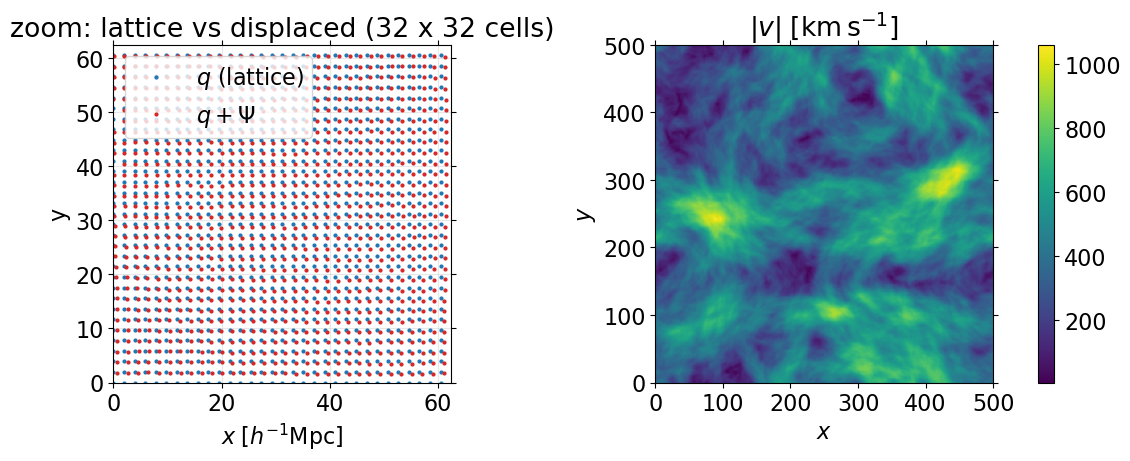

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

# Zoom showing lattice -> displaced particles
zoom = N // 8
ax[0].plot(qx[:zoom, :zoom].ravel(), qy[:zoom, :zoom].ravel(),
            'C0.', ms=4, label=r'$q$ (lattice)')
ax[0].plot(xx[:zoom, :zoom].ravel(), yy[:zoom, :zoom].ravel(),
            'C3.', ms=4, label=r'$q + \Psi$')
ax[0].set_aspect('equal')
ax[0].set_xlim(0, L*zoom/N); ax[0].set_ylim(0, L*zoom/N)
ax[0].set_xlabel(r'$x\;[h^{-1}\mathrm{Mpc}]$'); ax[0].set_ylabel('y')
ax[0].set_title(f'zoom: lattice vs displaced ({zoom} x {zoom} cells)')
ax[0].legend(); ax[0].grid(alpha=0.3)

vmag = np.sqrt(vx**2 + vy**2)
im = ax[1].imshow(vmag, cmap='viridis', origin='lower',
                   extent=[0, L, 0, L])
ax[1].set_title(r'$|v|\;[\mathrm{km\,s^{-1}}]$')
ax[1].set_xlabel(r'$x$'); ax[1].set_ylabel(r'$y$')
plt.colorbar(im, ax=ax[1], fraction=0.045)
plt.show()

## 5. Validation: recover the input $P(k)$ from the displaced particles

If the construction is right, depositing the displaced particles back
onto a CIC mesh and FFT'ing should give a power spectrum that matches
the input `th.Pk(k)`. The 2D per-mode normalization that makes the
units come out right is

$$P_{\rm meas}(\mathbf k) = \frac{dx^{2d}}{V}\,|\hat\delta_{\mathbf k}|^2 = \frac{V}{N^4}\,|\hat\delta_{\mathbf k}|^2.$$

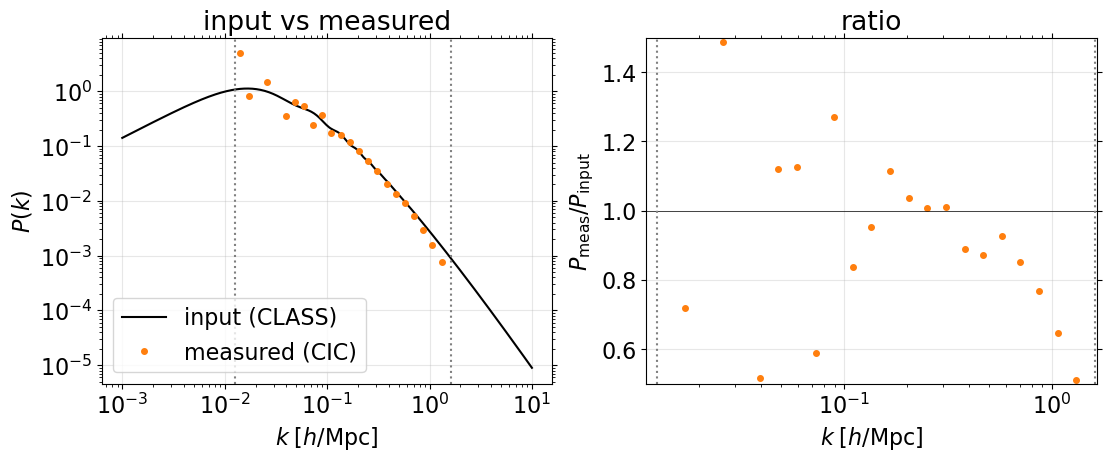

In [10]:
def cic_2d(pos, L, N):
    # 2D cloud-in-cell mass deposit on an N x N grid of side L.
    dx = L / N
    g  = pos / dx
    i0 = np.floor(g).astype(int)
    di = g - i0
    out = np.zeros((N, N))
    for ix in (0, 1):
        wx = (1 - di[:, 0]) if ix == 0 else di[:, 0]
        i  = (i0[:, 0] + ix) % N
        for iy in (0, 1):
            wy = (1 - di[:, 1]) if iy == 0 else di[:, 1]
            j  = (i0[:, 1] + iy) % N
            np.add.at(out, (i, j), wx * wy)
    return out

points  = np.column_stack([xx.ravel(), yy.ravel()])
rho     = cic_2d(points, L, N)
delta_m = rho / rho.mean() - 1
dk_m    = np.fft.fftn(delta_m)
P_modes = (V / N**4) * np.abs(dk_m)**2          # 2D: dx^{2d}/V = V/N^4

# Radial binning
edges = np.logspace(np.log10(2*np.pi/L), np.log10(0.9*np.pi/dx), 24)
ctrs  = 0.5 * (edges[:-1] + edges[1:])
P_meas = np.empty(len(ctrs))
for i in range(len(ctrs)):
    sel = (Kmag >= edges[i]) & (Kmag < edges[i+1])
    P_meas[i] = P_modes[sel].mean() if sel.any() else np.nan

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ax[0].loglog(k_show, th.Pk(k_show), 'k-', label='input (CLASS)')
ax[0].loglog(ctrs, P_meas, 'oC1', ms=4, label='measured (CIC)')
ax[0].axvline(2*np.pi/L, color='gray', ls=':')
ax[0].axvline(np.pi/dx,  color='gray', ls=':')
ax[0].set_xlabel(r'$k\;[h/\mathrm{Mpc}]$'); ax[0].set_ylabel(r'$P(k)$')
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title('input vs measured')

ax[1].semilogx(ctrs, P_meas/th.Pk(ctrs), 'oC1', ms=4)
ax[1].axhline(1, color='k', lw=0.5)
ax[1].axvline(2*np.pi/L, color='gray', ls=':')
ax[1].axvline(np.pi/dx,  color='gray', ls=':')
ax[1].set_xlabel(r'$k\;[h/\mathrm{Mpc}]$')
ax[1].set_ylabel(r'$P_{\rm meas} / P_{\rm input}$')
ax[1].set_ylim(0.5, 1.5); ax[1].grid(alpha=0.3)
ax[1].set_title('ratio')
plt.show()

## 6. The CIC window — why high-k is suppressed, and how to fix it

The measured curve in §5 falls below the input at high $k$ by a
predictable amount. That suppression is the **CIC mass-assignment
window**, not a flaw in the IC.

When a particle at position $\mathbf x$ is CIC-deposited to a grid with
spacing $dx$, its mass is split among the surrounding cells with
linear weights. That's a convolution of $\delta(\mathbf x)$ with the
CIC kernel; in Fourier it multiplies $\hat\delta(\mathbf k)$ by

$$W(\mathbf k) = \prod_a \cos\!\left(\tfrac{k_a\,dx}{2}\right)$$

(product over spatial axes $a$; equivalent to $\prod_a \mathrm{sinc}^2(k_a\,dx/2)$,
since the CIC kernel is the convolution of two NGP top-hats). The
measured power is therefore

$$P_{\rm meas}(\mathbf k) = W(\mathbf k)^2\,P_{\rm true}(\mathbf k).$$

At $k_a = k_{\rm Nyq}$, $\cos(\pi/2) = 0$ → full suppression. At $k_a =
k_{\rm Nyq}/2$, $W^2 = 0.5$, matching the §5 ratio plot. Dividing
$P_{\rm meas}$ by $W^2$ before binning ("deconvolution") removes the
bias. Production codes — including `icpipe.ICField.power` — do this,
and additionally use *interlacing* (Sefusatti+ 2016) to suppress
aliases past $k_{\rm Nyq}$. See `notes/cosmo_ic.pdf` Appendix B.

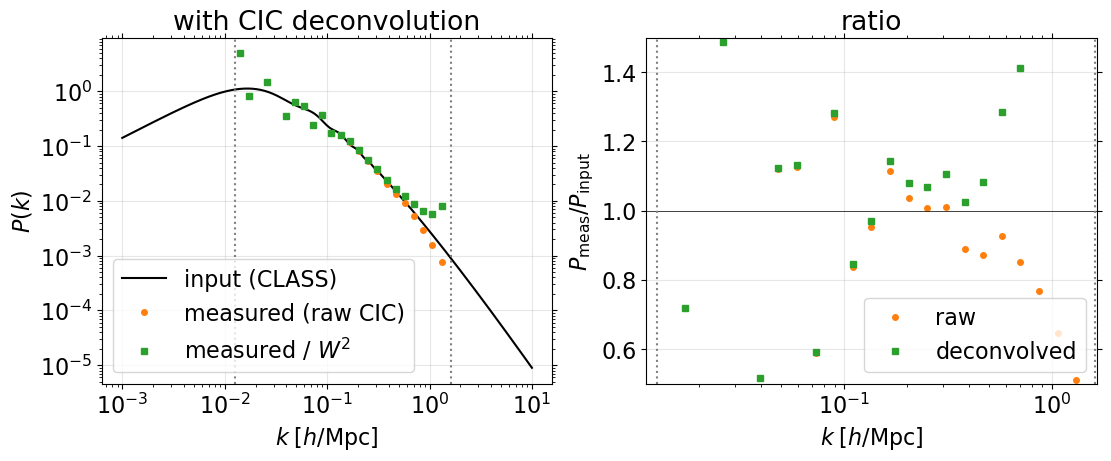

In [11]:
W2_2d = (np.cos(KX*dx/2) * np.cos(KY*dx/2))**2
W2_2d[0, 0] = 1.0                      # avoid 0/0 at DC

P_modes_dec = (V / N**4) * np.abs(dk_m)**2 / W2_2d

P_meas_dec = np.empty(len(ctrs))
for i in range(len(ctrs)):
    sel = (Kmag >= edges[i]) & (Kmag < edges[i+1])
    P_meas_dec[i] = P_modes_dec[sel].mean() if sel.any() else np.nan

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ax[0].loglog(k_show, th.Pk(k_show), 'k-', label='input (CLASS)')
ax[0].loglog(ctrs, P_meas,     'oC1', ms=4, label='measured (raw CIC)')
ax[0].loglog(ctrs, P_meas_dec, 'sC2', ms=4, label=r'measured / $W^2$')
ax[0].axvline(2*np.pi/L, color='gray', ls=':')
ax[0].axvline(np.pi/dx,  color='gray', ls=':')
ax[0].set_xlabel(r'$k\;[h/\mathrm{Mpc}]$'); ax[0].set_ylabel(r'$P(k)$')
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title('with CIC deconvolution')

ax[1].semilogx(ctrs, P_meas    /th.Pk(ctrs), 'oC1', ms=4, label='raw')
ax[1].semilogx(ctrs, P_meas_dec/th.Pk(ctrs), 'sC2', ms=4, label='deconvolved')
ax[1].axhline(1, color='k', lw=0.5)
ax[1].axvline(2*np.pi/L, color='gray', ls=':')
ax[1].axvline(np.pi/dx,  color='gray', ls=':')
ax[1].set_xlabel(r'$k\;[h/\mathrm{Mpc}]$')
ax[1].set_ylabel(r'$P_{\rm meas} / P_{\rm input}$')
ax[1].set_ylim(0.5, 1.5); ax[1].grid(alpha=0.3); ax[1].legend()
ax[1].set_title('ratio')
plt.show()

## 7. Interlacing — killing the leading aliases

§6 still overshoots near $k_{\rm Nyq}$. That residual is **aliasing**:
once particles are placed on a grid, modes with $|\mathbf k| > k_{\rm Nyq}$
fold back into the first Brillouin zone, and dividing by a small $W^2$
amplifies them. An unbiased estimator at coarse mode $\mathbf k_c$ is
the alias sum

$$\bigl\langle|\hat\delta_{\rm meas}(\mathbf k_c)|^2\bigr\rangle
  = \sum_{\mathbf n\in\mathbb Z^d}
    W^2(\mathbf k_c + 2 k_{\rm Nyq}\mathbf n)\,
    P\!\left(\mathbf k_c + 2k_{\rm Nyq}\mathbf n\right);$$

dividing by $W^2(\mathbf k_c)$ removes only the $\mathbf n=\mathbf 0$
term and leaves all the others.

**Sefusatti, Crocce, Pueblas & Scoccimarro (2016)** show that one extra
FFT cancels every alias copy with $\sum_a n_a$ odd — including the
dominant single-axis copies — at no other cost.

### Construction

Build a second CIC density on a grid offset by $\boldsymbol\Delta = dx/2$
along every axis, equivalently on the same grid but with particles
shifted by $+\boldsymbol\Delta/2$. The two grid samples are related by

$$\hat\rho_2(\mathbf k_c) = \sum_{\mathbf n} W(\mathbf k_n)\,
   \tilde\delta(\mathbf k_n)\,e^{-i\mathbf k_n\cdot\boldsymbol\Delta/2},
   \qquad \mathbf k_n \equiv \mathbf k_c + 2k_{\rm Nyq}\mathbf n.$$

Multiply $\hat\rho_2$ by $e^{+i\mathbf k_c\cdot\boldsymbol\Delta/2}$ to
align it with $\hat\rho_1$ at the *coarse* mode $\mathbf k_c$, and
average:

$$\hat\delta_{\rm int}(\mathbf k_c) =
   \tfrac{1}{2}\!\left[\hat\rho_1 + e^{i\mathbf k_c\cdot\boldsymbol\Delta/2}\,\hat\rho_2\right]
   = \sum_{\mathbf n} W(\mathbf k_n)\,\tilde\delta(\mathbf k_n)\,
     \tfrac{1}{2}\!\left[1 + e^{-i 2 k_{\rm Nyq}\mathbf n\cdot\boldsymbol\Delta/2}\right].$$

With $\boldsymbol\Delta = dx/2$ along each axis, $2k_{\rm Nyq}\mathbf n\cdot\boldsymbol\Delta/2 = \pi\sum_a n_a$, so

$$\tfrac{1}{2}\!\left[1 + (-1)^{\sum_a n_a}\right]
  = \begin{cases} 1 & \sum_a n_a \text{ even} \\ 0 & \sum_a n_a \text{ odd.}\end{cases}$$

**All single-axis aliases (the leading ones near $k_{\rm Nyq}$) are
killed exactly.** What survives sits at $|\mathbf k| \ge 2k_{\rm Nyq}$
where $W^2 P(k)$ is much smaller. After interlacing we still
deconvolve by $W^2(\mathbf k_c)$, but now the lift no longer amplifies
a large residual.

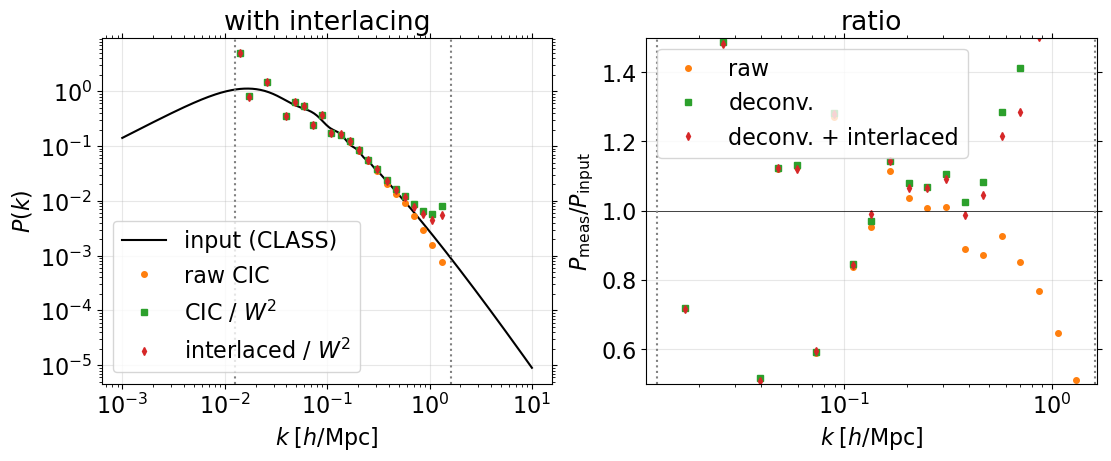

In [12]:
# Half-cell shift: deposit the same particles on a grid offset by dx/2.
points2 = (points + np.array([dx/2, dx/2])) % L
rho2    = cic_2d(points2, L, N)
delta_1 = rho  / rho.mean()  - 1
delta_2 = rho2 / rho2.mean() - 1

dk_1 = np.fft.fftn(delta_1)
dk_2 = np.fft.fftn(delta_2)

# Unshift phase, then average. Sign convention matches icpipe.ICField.
phase  = np.exp(1j * (KX + KY) * dx / 2)
dk_int = 0.5 * (dk_1 + phase * dk_2)

P_modes_int = (V / N**4) * np.abs(dk_int)**2 / W2_2d

P_meas_int = np.empty(len(ctrs))
for i in range(len(ctrs)):
    sel = (Kmag >= edges[i]) & (Kmag < edges[i+1])
    P_meas_int[i] = P_modes_int[sel].mean() if sel.any() else np.nan

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

ax[0].loglog(k_show, th.Pk(k_show), 'k-', label='input (CLASS)')
ax[0].loglog(ctrs, P_meas,     'oC1', ms=4, label='raw CIC')
ax[0].loglog(ctrs, P_meas_dec, 'sC2', ms=4, label=r'CIC / $W^2$')
ax[0].loglog(ctrs, P_meas_int, 'dC3', ms=4, label=r'interlaced / $W^2$')
ax[0].axvline(2*np.pi/L, color='gray', ls=':')
ax[0].axvline(np.pi/dx,  color='gray', ls=':')
ax[0].set_xlabel(r'$k\;[h/\mathrm{Mpc}]$'); ax[0].set_ylabel(r'$P(k)$')
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title('with interlacing')

ax[1].semilogx(ctrs, P_meas    /th.Pk(ctrs), 'oC1', ms=4, label='raw')
ax[1].semilogx(ctrs, P_meas_dec/th.Pk(ctrs), 'sC2', ms=4, label='deconv.')
ax[1].semilogx(ctrs, P_meas_int/th.Pk(ctrs), 'dC3', ms=4, label='deconv. + interlaced')
ax[1].axhline(1, color='k', lw=0.5)
ax[1].axvline(2*np.pi/L, color='gray', ls=':')
ax[1].axvline(np.pi/dx,  color='gray', ls=':')
ax[1].set_xlabel(r'$k\;[h/\mathrm{Mpc}]$')
ax[1].set_ylabel(r'$P_{\rm meas} / P_{\rm input}$')
ax[1].set_ylim(0.5, 1.5); ax[1].grid(alpha=0.3); ax[1].legend()
ax[1].set_title('ratio')
plt.show()

The diamond curve sits at unity essentially all the way to $k_{\rm Nyq}$
— the construction is now **alias-free at first order**. This is what
`icpipe.ICField.power('delta')` does internally (in 3D, with an
additional optional shot-noise subtraction). The remaining wiggle very
near $k_{\rm Nyq}$ is from the surviving even-$\sum n_a$ aliases plus
the lattice's residual sub-Poissonian shot noise; both are small
because at $z=200$ the displacements are well below a cell size.

## From this 2D toy to the production pipeline

The 3D code MUSIC2 (`./music_build/MUSIC`, driven by
`run_pipeline.sh`) does exactly the same thing on a 3D grid, plus:

- **3D** — identical algorithm, with $k^2 = k_x^2 + k_y^2 + k_z^2$ and
  $\boldsymbol\Psi$ a 3-vector.
- **2LPT** — a second-order correction $\boldsymbol\Psi^{(2)}$ that
  improves accuracy at later $z_{\rm start}$ (`notes/cosmo_ic.pdf` §2LPT).
- **Multi-species** — separate $\delta_{\rm cdm}$, $\delta_b$ fields
  with their own transfer functions (CDM-only here; baryons planned —
  see `notes/baryon_ic_plan.md`).
- **Refinement hierarchy** — zoom regions with extra resolution
  (`notes/restriction_lpt.pdf` covers what happens to $\boldsymbol\Psi$
  and $\delta$ under block-averaging).
- **PLT corrections** — small adjustments that reconcile lattice and
  continuum derivatives.
- **Back-scaling** — input $P(k)$ taken at $z=0$ and scaled to
  $z_{\rm start}$ by $D(z)$, so the linear theory and N-body growth
  agree at $z_{\rm start}$.
- **HDF5 output** in SWIFT format: positions in Mpc (not Mpc/h),
  `Velocities` storing $v_{\rm pec}$ in km/s. Convention details in
  the project `CLAUDE.md`.

Once you have an HDF5 file, `01_quickstart.ipynb` and
`02_box_size_sensitivity.ipynb` show the same kind of validation done
in §5 above, but on real 3D ICs and through `icpipe.ICField`.

## Where to read more

- `notes/cosmo_ic.pdf` — fluid equations, ZA, 2LPT, P(k) measurement,
  MUSIC2 internals (transfer functions, Poisson solve, PLT, back-scaling).
- `notes/ic_sampling.pdf` — IC sampling subtleties (P-sampled vs
  ξ-sampled, box-window truncation).
- `notes/fft.pdf` — Fourier conventions, DFT, FFTW.
- `notes/restriction_lpt.pdf` — block-averaging restriction and 1LPT.
- `CLAUDE_MUSIC2.md` — running and configuring MUSIC2.